# Exploratory Data Analysis with Simple ML Models
This notebook demonstrates how simple machine learning models can be used as *exploratory tools* to assess data structure and quality.

In [19]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler



## 1. Load and Inspect the Data

In [20]:
iris = load_iris(as_frame=True)
df = iris.frame


In [32]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [22]:
df.isna().any()

sepal length (cm)    False
sepal width (cm)     False
petal length (cm)    False
petal width (cm)     False
target               False
dtype: bool

In [23]:
df.duplicated().sum()

np.int64(1)

In [33]:
df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
142,5.8,2.7,5.1,1.9,2


In [34]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [26]:
df.nunique()

sepal length (cm)    35
sepal width (cm)     23
petal length (cm)    43
petal width (cm)     22
target                3
dtype: int64

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


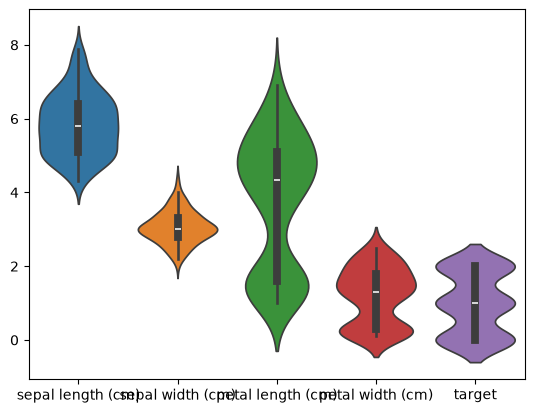

In [29]:
sns.violinplot(df)
plt.show()

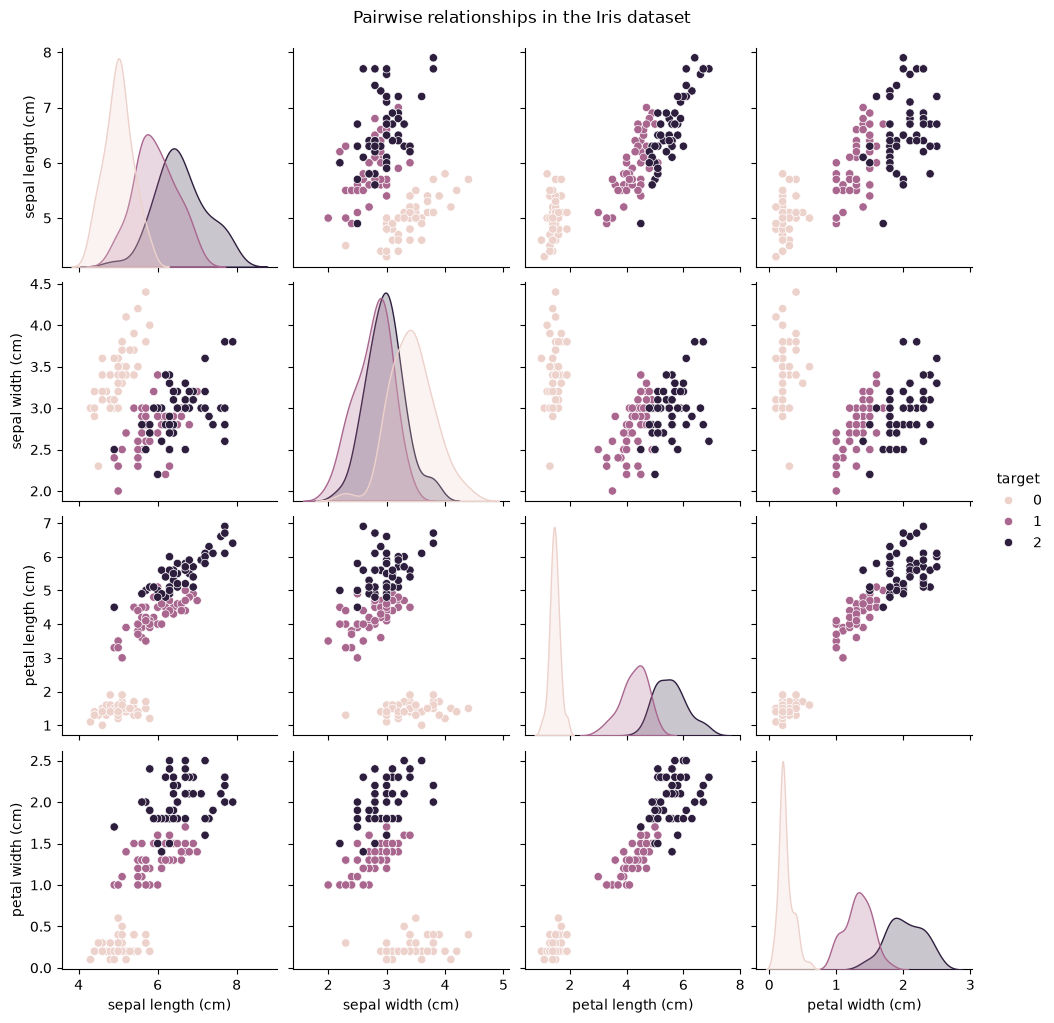

In [30]:
sns.pairplot(df, hue='target', diag_kind='kde')
plt.suptitle("Pairwise relationships in the Iris dataset", y=1.02)
plt.show()

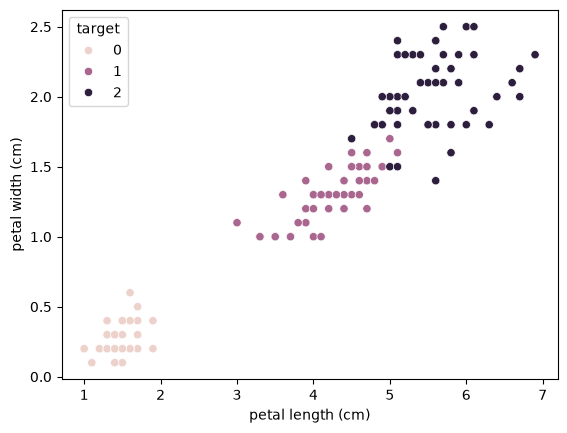

In [37]:
sns.scatterplot(x=df["petal length (cm)"], y=df["petal width (cm)"], hue=df["target"])
plt.show()

## 2. Recap Dimensionality Reduction (PCA)

Load the dataset directly from scikit-learn (quite a few classic datasets are available):

In [38]:
X = df[iris.feature_names]
y = df['target']

Standardise features:

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Perform PCA:

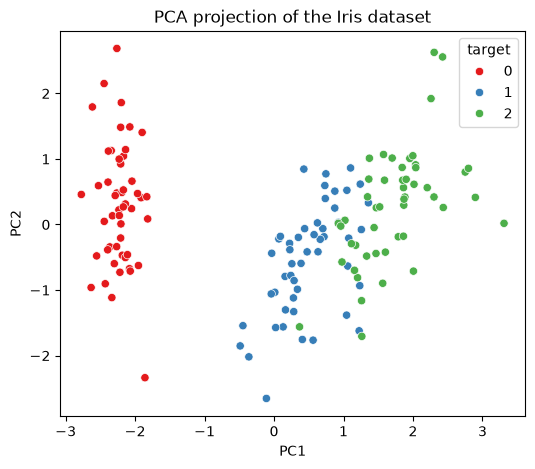

PC1 (73.0% variance)
PC2 (22.9% variance)


In [40]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1')
plt.title("PCA projection of the Iris dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
print(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

## 3. Using Simple ML Models as EDA Tools

Pseudorandom split the data in training data and test data for evaluating the prediction. The stratify parameter ensures that the targets are evenly represented in the split data sets

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

Apply scaling to training and test set independently:

In [42]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### a) Logistic Regression

Is a regression model suitable for a classification problem?

In [43]:
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train_scaled, y_train)

print("Train accuracy:", logreg.score(X_train_scaled, y_train))
print("Test accuracy:", logreg.score(X_test_scaled, y_test))

Train accuracy: 0.9809523809523809
Test accuracy: 0.9111111111111111


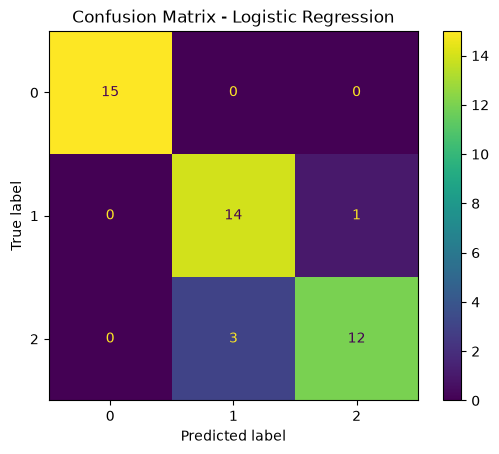

In [44]:
ConfusionMatrixDisplay.from_estimator(logreg, X_test_scaled, y_test)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### b) Decision Tree Classifier

Tree-based models do not need scaling and can work on the original data.

Train accuracy: 0.9809523809523809
Test accuracy: 0.9777777777777777


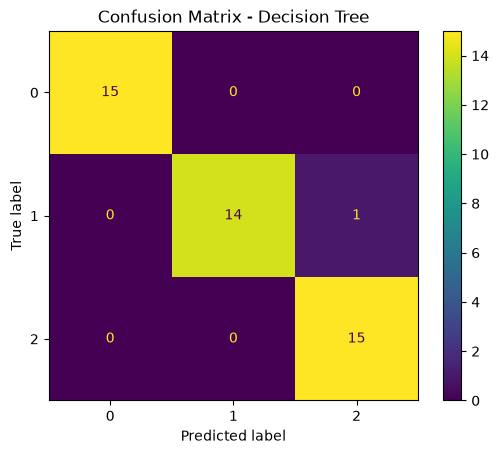

In [47]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

print("Train accuracy:", tree.score(X_train, y_train))
print("Test accuracy:", tree.score(X_test, y_test))

ConfusionMatrixDisplay.from_estimator(tree, X_test, y_test)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

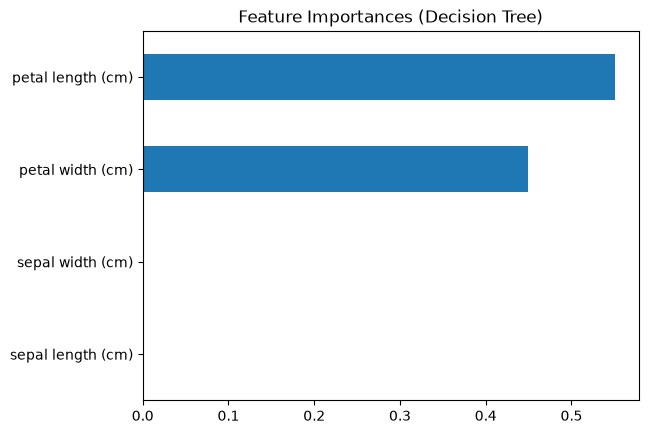

In [48]:
feat_importances = pd.Series(tree.feature_importances_, index=iris.feature_names)
feat_importances.sort_values().plot(kind='barh')
plt.title("Feature Importances (Decision Tree)")
plt.show()

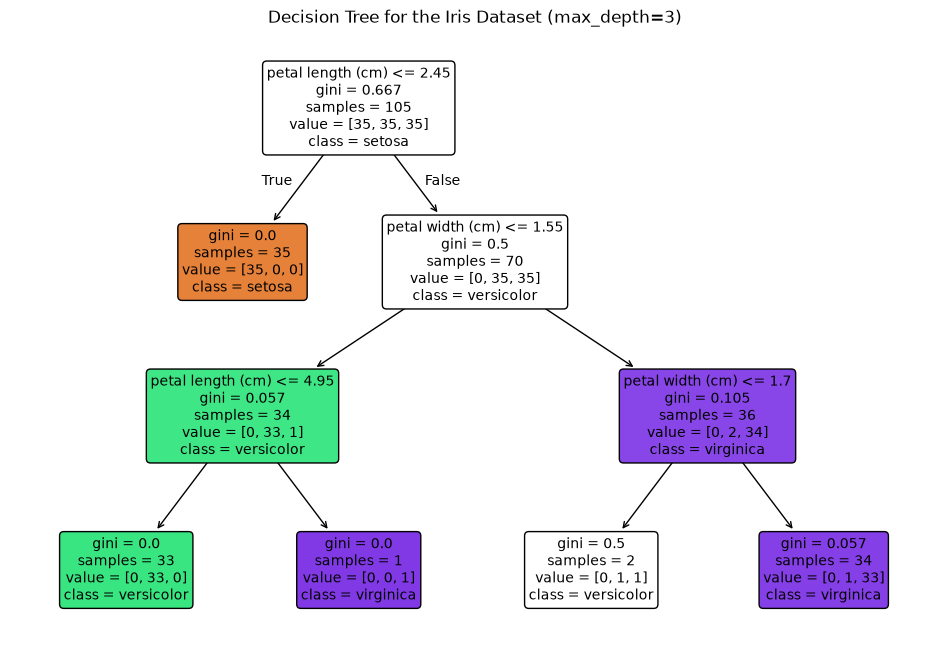

In [49]:
plt.figure(figsize=(12,8))
plot_tree(
    tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for the Iris Dataset (max_depth=3)")
plt.show()

## 4. Quick Model Diagnostics

Testing generalisation by cross validation

In [50]:
cv_scores = cross_val_score(tree, X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", cv_scores.mean())

Cross-validation scores: [0.96666667 0.96666667 0.93333333 1.         1.        ]
Mean accuracy: 0.9733333333333334


Rerun on PCA features to compare loss of predictive capabilities:

In [51]:
X_pca_full = PCA(n_components=2).fit_transform(X)
tree.fit(X_pca_full, y)
print("Decision Tree accuracy on 2D PCA features:", cross_val_score(tree, X_pca_full, y, cv=5).mean())

Decision Tree accuracy on 2D PCA features: 0.9133333333333334


## 5. Wrap-Up & Reflection

In [52]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [53]:
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree (depth=3)"],
    "Train Accuracy": [logreg.score(X_train_scaled, y_train), tree.score(X_train, y_train)],
    "Test Accuracy": [logreg.score(X_test_scaled, y_test), tree.score(X_test, y_test)]
})
summary

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.980952,0.911111
1,Decision Tree (depth=3),0.980952,0.977778


What can we take away from this?